---
title: "Курсова робота на тему \"Векторні представлення слів на основі співзустрічальності\""
description: "Технології аналізу текстової інформації та машинне навчання | КрНУ ім. М. Остроградського"
Виконав: "студент групи КН-25-1м Роменський В'ячеслав"
Перевірив: ".."

format:
  html:
    code-fold: show
    code-summary: "Показати код"
    code-overflow: wrap
    toc: true
    toc-depth: 4
    toc-location: right
    number-sections: false
    embed-resources: true
    smooth-scroll: true
---

# Мета роботи

Метою роботи є виконання практичної реалізації алгоритму побудови word embeddings на основі обраного тексту через матрицю співзустрічальності та SVD, а також здійснення аналізу отриманих результатів.

# Постановка задачі

Обов'язково треба створити корпус коротких текстів із рекомендованим обсягом корпусу: від 150 до 1000 текстів. Дані мають бути описані та сформовані для подальшого аналізу. Обов'язково дані мають бути очищені. Треба провести базове очищення тексту, токенізацію, побудову частотного словника, побудову TF-IDF-представлення, побудувати модель та оцінити результати.

Варіант, що був обраний для виконання, це векторні представлення слів на основі співзустрічальності. Необхідно сформувати невеликий корпус, побудувати словник, побудувати матрицю співзустрічальності, обчислити log(cooc + 1), отримати 2D-вектори слів через SVD, візуалізувати близькість слів. Мінімальним результатом є: матриця співзустрічальності, 2D-графік слів, пояснення семантичної близькості.

# Опис даних

Для реалізації та дослідження моделі векторного представлення слів на основі співзустрічальності було використано текстовий корпус "ABC" (Australian Broadcasting Corporation), який є частиною стандартного набору даних бібліотеки NLTK (Natural Language Toolkit).

Корпус abc складається з реальних новинних текстів та журналістських матеріалів австралійського медіапростору. Тематика цього корпусу охоплює переважно інформаційні повідомлення, пов'язані з економікою, внутрішньою політикою, аграрним сектором, науковими дослідженнями та глобальними міжнародними новинами. Мова корпусу — англійська.

Саме такий корпус даних було обрано для того, аби слова часто зустрічались у схожих контекстах. Новини будують навколо конкретних подій та фактів, тому явно будуть виявлятись паттерни.

# Підготовка середовища

Для виконання курсової роботи було використано середовище розробки Positron із використанням Python 3.11.15. Було використано наступні біблотеки:

- nltk (Natural Language Toolkit) Центральний інструмент для попередньої обробки тексту. Використовується для завантаження вхідного корпусу новин (abc), токенізації речень, видалення загальномовних стоп-слів (stopwords) та розрахунку частотного розподілу токенів за допомогою класу FreqDist для формування фінального словника.

- numpy (NumPy) Фундаментальна бібліотека для високопродуктивних наукових та матричних обчислень. У даній роботі за допомогою неї здійснювалося ініціалізація та заповнення двовимірної матриці співзустрічальності, математичне згладжування даних через функцію np.log1p, а також безпосереднє виконання сингулярного розкладання (SVD) за допомогою вбудованого модуля лінійної алгебри np.linalg.svd.

- pandas (Pandas) Бібліотека для маніпулювання та аналізу структурованих даних. Вона дозволила об'єднати результати обчислення косинусної міри між унікальними парами слів у зручний табличний формат (DataFrame), виконати швидке сортування зв'язків за спаданням та структурувати дані для подальшого аналізу.

- matplotlib (Matplotlib) Основний інструмент для двовимірної графічної візуалізації. Використовується для побудови фінального діаграми розсіяння (Scatter Plot), що відображає розташування векторів слів на площині в осях двох перших головних компонент SVD.

- adjustText Спеціалізоване мікророзширення для Matplotlib. Бібліотека вирішує проблему накладання текстових міток (назв слів) одна на одну та на самі координатні точки. Завдяки ітеративному алгоритму вона автоматично «розсуває» написи на графіку, роблячи його повністю читабельним.

- sklearn (Scikit-learn) Пакет інструментів для машинного навчання та аналізу даних. З цієї бібліотеки було взято функцію cosine_similarity, яка є стандартом в NLP для точного математичного розрахунку кута між багатовимірними векторами та визначення ступеня їхньої семантичної близькості, а також TfidfVectorizer для виконання побудови TF-IDF-представлення.

In [289]:
import nltk
from nltk.corpus import abc
from nltk.corpus import stopwords

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from adjustText import adjust_text

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

# Завантаження даних

Для роботи було обрано взяти перші 200 текстів із корпусу abc. Тексти одразу ж подаються у токенізованій формі. Спочатку було виконано завантаження текстів за допомогою nltk.download і обрано корпус коротних новинних текстів. Початково речення збережемо у змінній sentences.

In [290]:
nltk.download('abc') # Корпус коротких новинних текстів (англійською)
sentences = abc.sents()[:200] # Перші 200 речень

[nltk_data] Downloading package abc to
[nltk_data]     C:\Users\suziu\AppData\Roaming\nltk_data...
[nltk_data]   Package abc is already up-to-date!


Перший текст у корпусі виглядає наступним чином. Можна помітити, що слова просто поділені між собою, але ніяк не оброблені, чим і треба зайнятись на наступному етапі.

In [291]:
sentences[0]

['PM',
 'denies',
 'knowledge',
 'of',
 'AWB',
 'kickbacks',
 'The',
 'Prime',
 'Minister',
 'has',
 'denied',
 'he',
 'knew',
 'AWB',
 'was',
 'paying',
 'kickbacks',
 'to',
 'Iraq',
 'despite',
 'writing',
 'to',
 'the',
 'wheat',
 'exporter',
 'asking',
 'to',
 'be',
 'kept',
 'fully',
 'informed',
 'on',
 'Iraq',
 'wheat',
 'sales',
 '.']

# Попередня обробка тексту

Перше, що було виконано, це переведення слів у нижній регістр та вилучення будь-якого токена, що не містить жодного буквенного символу. У результаті кожен текст чисто поділений на слова та не має чисел, знаків пунктуації, а також різниці між словами із великої літери та з малої.

In [292]:
corpus = [[word.lower() for word in sent if word.isalpha()] for sent in sentences]
corpus[0]

['pm',
 'denies',
 'knowledge',
 'of',
 'awb',
 'kickbacks',
 'the',
 'prime',
 'minister',
 'has',
 'denied',
 'he',
 'knew',
 'awb',
 'was',
 'paying',
 'kickbacks',
 'to',
 'iraq',
 'despite',
 'writing',
 'to',
 'the',
 'wheat',
 'exporter',
 'asking',
 'to',
 'be',
 'kept',
 'fully',
 'informed',
 'on',
 'iraq',
 'wheat',
 'sales']

Також обов'язковим є те, що із тексту необхідно вирізати усі слова, які не будуть нести для нас жодної користі у подальному аналізі, а лише будуть заважати нам зрозуміти щось про слова, які мають сенсове навантаження та можуть розповісти нам про тематику текстів.

Для того, аби прибрати зайві стоп-слова, було обрано до завантаження сет стоп-слів англійською мовою із бібліотеки nltk.

Після обробки стало помітно менше слів у текстах.

In [293]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
stop_words.update(['says', 'said', 'think', 'get', 'new'])

cleaned_corpus = []
for sent in corpus:
    cleaned_sent = [
        word for word in sent 
        if word.isalpha() and word not in stop_words
    ]
    cleaned_corpus.append(cleaned_sent)

cleaned_corpus[0]

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\suziu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


['pm',
 'denies',
 'knowledge',
 'awb',
 'kickbacks',
 'prime',
 'minister',
 'denied',
 'knew',
 'awb',
 'paying',
 'kickbacks',
 'iraq',
 'despite',
 'writing',
 'wheat',
 'exporter',
 'asking',
 'kept',
 'fully',
 'informed',
 'iraq',
 'wheat',
 'sales']

# Розвідувальний аналіз корпусу

Перш ніж переходити до побудови матриці співзустрічальності та навчання моделей, необхідно виконати якісний та кількісний аналіз текстових даних. Розвідувальний аналіз корпусу у реалізовано двома методами: за допомогою класичного частотного аналізу (nltk.FreqDist) та за допомогою статистичного зважування важливості слів у документах (TF-IDF).

Для визначення найбільш уживаної лексики було підраховано всі слова очищеного корпусу cleaned_corpus та розраховано їхні абсолютні частоти. На основі отриманого розподілу було сформовано робочий словник експерименту, куди увійшли 30 найчастіших слів.

Результати наступні: за 200 текстів після очищення загалом залишилось 2572 слова, 1392 із яких є унікальними, тобто складають розмір словнику. Найчастішими словами є наступні: Австралія, AWB, рік, фермери, Зеландія, один тощо. За цим аналізом вже можна зрозуміти те, що новини базуються навколо Австралії та її сусідських країн, а також дуже багато інформації саме про сільське господарство.

In [294]:
all_words = [word for sent in cleaned_corpus for word in sent]
freq_dist = nltk.FreqDist(all_words)

top_vocab = [word for word, freq in freq_dist.most_common(30)]
word_to_idx = {word: idx for idx, word in enumerate(top_vocab)}
top_vocab_size = len(top_vocab)

print("Загальна кількість слів:", len(all_words))
print("Розмір словнику:", len(freq_dist))
print("Найчастіші слова:")
freq_dist.most_common(20)

Загальна кількість слів: 2572
Розмір словнику: 1392
Найчастіші слова:


[('australia', 27),
 ('awb', 22),
 ('year', 14),
 ('farmers', 13),
 ('zealand', 13),
 ('one', 12),
 ('mr', 12),
 ('growers', 12),
 ('south', 12),
 ('prices', 12),
 ('people', 12),
 ('iraq', 11),
 ('wheat', 11),
 ('market', 11),
 ('last', 11),
 ('food', 10),
 ('time', 10),
 ('industry', 10),
 ('minister', 9),
 ('inquiry', 9)]

Оскільки абсолютна частота (FreqDist) фіксує лише абсолютну кількість повторів слів і часто виносить на перші місця загальновживані слова (наприклад, year або one), було застосовано складніший метод зважування — TF-IDF (Term Frequency - Inverse Document Frequency). Категорією «документа» в межах даного аналізу виступало кожне окреме речення корпусу.

Результати обчислення середнього значення TF-IDF для топ-15 найважливіших токенів виведено у вигляд таблиці. Можна зазначити, що обидва списки дуже схожі, що каже про те, що відібрані слова є справді дуже інформативні і можна використовувати для подальшої роботи.

In [295]:
# Перетворюємо список токенів назад у рядки (бо TfidfVectorizer приймає текст)
string_corpus = [" ".join(sent) for sent in cleaned_corpus]

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(string_corpus)

feature_names = vectorizer.get_feature_names_out()
mean_tfidf = tfidf_matrix.mean(axis=0).A1

df_tfidf = pd.DataFrame({'Слово': feature_names, 'Середній TF-IDF': mean_tfidf})
df_tfidf = df_tfidf.sort_values(by='Середній TF-IDF', ascending=False).reset_index(drop=True)

display(df_tfidf.head(15))

,Слово,Середній TF-IDF
0,australia,0.020313
1,awb,0.019648
2,mr,0.016327
3,year,0.012867
4,people,0.012056
5,south,0.011999
6,growers,0.011866
7,prices,0.011709
8,one,0.011649
9,farmers,0.011499


# Векторизація текстів

Етап векторизації є ключовим переходом від текстових токенів до числових представлень. У цій роботі реалізовано дистрибутивно-семантичний підхід, що базується на гіпотезі локального контексту: слова, які вживаються у схожому оточенні, мають близькі за значенням вектори. Процес векторизації складається з трьох послідовних кроків: побудови матриці співзустрічальності (Co-occurrence Matrix), логарифмічного згладжування частот та зниження розмірності за допомогою сингулярного розкладу (SVD).

### Побудова матриці співзустрічальності

На основі сформованого робочого словника найчастіших слів було ініціалізовано квадратну матрицю cooc_matrix розмірністю $V \times V$ (де $V = 30$ — розмір словника), заповнену нулями.

Для заповнення матриці застосовано алгоритм «рухомого вікна» (Sliding Window) із фіксованим радіусом контексту $w = 2$. Алгоритм проходить по кожному реченню очищеного корпусу і формує симетричну матрицю, де кожен рядок це вектор слова, що описує його схильність до сусідства із іншими словами корпусу.

### Логарифмічне згладжування частот

Аби не використовувати напряму абсолютні частоти появи слів, то ми здійснюємо перетворення значень через логарифм. Таким чином слова, що мають дуже високу частоту появи, не будуть зашумлювати зв'язки із іншими словами. Це згладжування стискає діапазон великих чисел, зберігаючи при цьому відносний порядок значущості зв'язків.

In [296]:
# Побудова матриці співзустрічальності (Вікно контексту = 2)
window_size = 2
cooc_matrix = np.zeros((top_vocab_size, top_vocab_size))

for sent in cleaned_corpus:
    for i, word in enumerate(sent):
        if word in word_to_idx:
            idx_w = word_to_idx[word]
            # Визначаємо межі вікна контексту
            start = max(0, i - window_size)
            end = min(len(sent), i + window_size + 1)
            
            for j in range(start, end):
                if i != j and sent[j] in word_to_idx:
                    idx_context = word_to_idx[sent[j]]
                    cooc_matrix[idx_w, idx_context] += 1

# Обчислення log(cooc + 1)
log_cooc_matrix = np.log1p(cooc_matrix)

# Побудова основної моделі

Виконуємо зниження розмірності за допомогою SVD.Початкова матриця log_cooc_matrix задає простір, де кожне слово описується 30-вимірним вектором. Для можливості візуалізації на площині та ущільнення інформації необхідно знизити розмірність до $d = 2$. Для цього було застосовано метод сингулярного розкладу матриці (SVD), що розкладає матрицю на добуток трьох матриць. Аби взяти найбільш значущі компоненти, необхідно взяти перші два стопвці матриці $U$.

In [ ]:
U, S, Vt = np.linalg.svd(log_cooc_matrix)
# Беремо перші два стовпці матриці U, щоб отримати координати (x, y)
word_vectors_2d = U[:, :2]

# Оцінювання якості або інтерпретація

Візуалізуємо графік за допомогою mathplotlib та adjust_text. Ми можемо бачити 2D-простір слів на основі SVD та матриці співзустрічальності, де розкидані точки, що підписані словом.

Аналіз просторового розподілу точок дозволяє виділити чітку семантичну структуру даних та ідентифікувати кілька виражених тематичних зон і закономірностей:

1. Аграрно-торговельний кластер.

У правій частині графіку можна побачити велике скупчення точок, що вказує на доволі високу однорідність тематики текстів. Бачимо такі слова, як grain (зерно), fruit (фрукти), zealand (Нова Зеландія), hay (сіно), wool (вовна), river (річка) дуже близько одне до одного. Недалеко також є слова growers (виробники), farmers (фермери) та prices (ціни), що доповнюють економічний контекст.

2. Політичний кластер.

Вектор, що примикає знизу до аграрного кластера є наступна група слів: government (уряд), food (продовольство), inquiry (розслідування), minister (міністр), people (народ). Але загалом треба відмітити, що цей кластер дуже тісно переплітається із минулим, бо трапляються в текстах майже одночасно.

3. Пшеничний експорт.

Дуже яскраво можна побачити пару точок wheat (пшениця) та iraq (Ірак). Поруч із ними, але ближче до центру, розташовані абревіатура awb (Австралійська пшенична рада) та слово market (ринок), що підкреслює економічну природу цього ізольованого сюжету.

4. Абстрактні та часові орієнтири.

Слова, що виражають часові поняття — time та year — зайняли медіанне (центральне) положення на графіку та вишикувалися вздовж однієї лінії. Будучи універсальними контекстними маркерами новинного жанру (вказівки на події минулого року чи поточного часу), вони слугують сполучними ланками для різних тематичних блоків.

5. Поодинокі викиди.

Лексеми australia та south опинилися на верхній периферії графіка. Оскільки це загальні географічні назви, висока частота їх використання у поєднанні з різноманітними унікальними контекстами (наприклад, "South Australia", "South Africa" або згадки країни в цілому) змусила алгоритм SVD винести їх за межі щільних кластерів, щоб зберегти ортогональність щодо вузькоспеціалізованих слів.

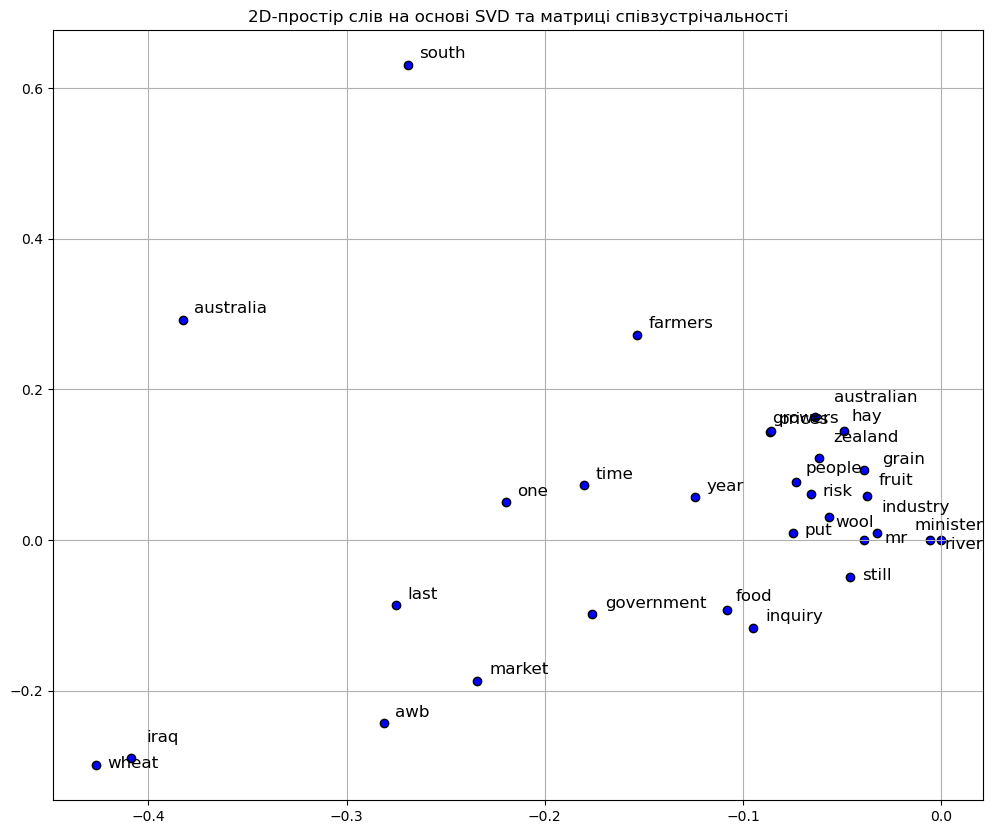

In [298]:
plt.figure(figsize=(12, 10))
plt.scatter(word_vectors_2d[:, 0], word_vectors_2d[:, 1], color='blue', edgecolors='k')

texts = []
for word, idx in word_to_idx.items():
    t = plt.text(word_vectors_2d[idx, 0] + 0.005, word_vectors_2d[idx, 1] + 0.005, word, fontsize=12)
    texts.append(t)

plt.title("2D-простір слів на основі SVD та матриці співзустрічальності")
plt.grid(True)

adjust_text(texts)

plt.show()

Далі було обчислено матрицю косинусної близькості, де слова, що знаходяться по одну сторону від початку координат, тобто мають схожий кут, будуть мати більше значення близькості. Можемо побачити наступні дуже близькі за контекстом навколо них слова: zealand fruit та iraq wheat є дуже популярними парами.

In [299]:
cos_sim_matrix = cosine_similarity(log_cooc_matrix)

pairs_data = []

for i in range(vocab_size):
    for j in range(i + 1, vocab_size):
        pairs_data.append({
            'Слово 1': vocab[i],
            'Слово 2': vocab[j],
            'Косинусна міра': cos_sim_matrix[i, j]
        })

df_similarity = pd.DataFrame(pairs_data)
df_similarity = df_similarity.sort_values(by='Косинусна міра', ascending=False).reset_index(drop=True)
display(df_similarity.head(15))

,Слово 1,Слово 2,Косинусна міра
0,zealand,fruit,0.734384
1,iraq,wheat,0.727890
2,time,risk,0.716273
3,minister,still,0.707107
4,industry,australian,0.707107
5,wheat,government,0.690028
6,wheat,market,0.683465
7,last,time,0.679088
8,market,last,0.679088
9,farmers,south,0.678480


# Порівняння із неочищеними даними

Якщо використати корпус таким, яким він був без його очистки від стоп-слів, то на графіку ми можемо побачити лише дуже велику кількість беззмістовних слів, за якими ми ніяк не можемо оцінити вміст текстів. Єдине слово, що дозволяє нам це зробити - australia.

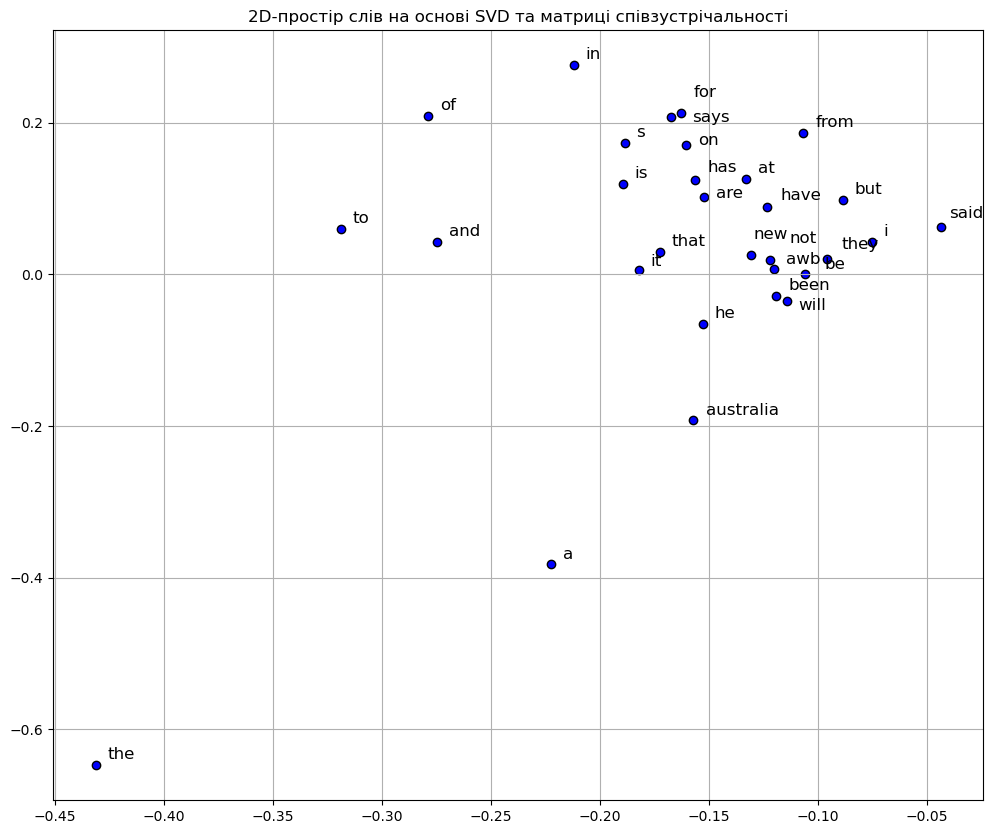

In [301]:
all_words = [word for sent in corpus for word in sent]
freq_dist = nltk.FreqDist(all_words)

top_vocab = [word for word, freq in freq_dist.most_common(30)]
word_to_idx = {word: idx for idx, word in enumerate(top_vocab)}
top_vocab_size = len(top_vocab)

window_size = 2
cooc_matrix = np.zeros((top_vocab_size, top_vocab_size))

for sent in corpus:
    for i, word in enumerate(sent):
        if word in word_to_idx:
            idx_w = word_to_idx[word]
            start = max(0, i - window_size)
            end = min(len(sent), i + window_size + 1)
            
            for j in range(start, end):
                if i != j and sent[j] in word_to_idx:
                    idx_context = word_to_idx[sent[j]]
                    cooc_matrix[idx_w, idx_context] += 1

log_cooc_matrix = np.log1p(cooc_matrix)

U, S, Vt = np.linalg.svd(log_cooc_matrix)
word_vectors_2d = U[:, :2]

plt.figure(figsize=(12, 10))
plt.scatter(word_vectors_2d[:, 0], word_vectors_2d[:, 1], color='blue', edgecolors='k')

texts = []
for word, idx in word_to_idx.items():
    t = plt.text(word_vectors_2d[idx, 0] + 0.005, word_vectors_2d[idx, 1] + 0.005, word, fontsize=12)
    texts.append(t)

plt.title("2D-простір слів на основі SVD та матриці співзустрічальності")
plt.grid(True)

adjust_text(texts)

plt.show()

# Висновки

За результатами виконання роботи можна зробити такі висновки:

1. Ефективність попередньої обробки. Етап глибокого очищення тексту (видалення пунктуації, приведення до нижнього регістру та розширення списку стоп-слів журналістськими маркерами мовлення said, says) дозволив позбутися синтаксичного шуму й сформувати інформаційно насичене ядро з 30 найчастіших лексем для побудови словника.

2. Важливість статистичного аналізу (EDA). Комбінація частотного аналізу (FreqDist) та метрики TF-IDF підтвердила тематичну концентрованість підкорпусу новин ABC навколо аграрного експорту, економіки та внутрішньої політики Австралії, виділивши ключові інформаційні домінанти (australia, awb, wheat, iraq).

3. Математична коректність векторизації. Застосування нелінійного логарифмічного згладжування $\log(x + 1)$ дозволило стабілізувати масштаб матриці співзустрічальності та нівелювати домінування надчастотних слів. Використання сингулярного розкладу (SVD) із виділенням двох перших головних компонент забезпечило геометрично точне стиснення простору до 2D-площини із збереженням максимуму дисперсії.

4. Об'єктивність семантичного картування.Фінальна візуалізація та розрахована матриця косинусної близькості повністю підтвердили дистрибутивну гіпотезу. Модель автоматично згрупувала слова у логічні кластери: аграрно-виробничий (grain–fruit–wool–hay), політико-адміністративний (government–minister–inquiry), а також успішно локалізувала унікальний ізольований сюжет торговельних відносин (wheat–iraq із косинусною мірою $0.728$).

Поставлені завдання виконано в повному обсязі, мета роботи досягнута. Розроблена модель довела, що навіть класичні статистичні підходи лінійної алгебри без залучення складних нейромережевих архітектур здатні ефективно моделювати людську мову, виявляти приховані смислові зв'язки та формувати якісні векторні простори слів.

# Список використаних джерел

1. Офіційна документація модуля пакетної візуалізації Matplotlib. 2026. URL: https://matplotlib.org/ (дата звернення: 21.05.2026).

2. Scikit-learn: Machine Learning in Python. Pairwise metrics: Cosine Similarity. scikit-learn developers. 2026. URL: https://scikit-learn.org/stable/modules/metrics.html (дата звернення: 21.05.2026).

3. NumPy Documentation: Linear algebra (numpy.linalg). NumPy v1.26 Manual. 2025. URL: https://numpy.org/doc/stable/reference/routines.linalg.html (дата звернення: 21.05.2026).

4. Natural Language Toolkit (NLTK) Documentation. NLTK Project. 2026. URL: https://www.nltk.org/ (дата звернення: 21.05.2026).

5. Pandas Documentation: API Reference for DataFrame. Pandas data analysis toolkit. 2026. URL: https://pandas.pydata.org/docs/reference/frame.html (дата звернення: 21.05.2026).

6. adjustText: Automatic label placement for matplotlib. GitHub Repository. 2025. URL: https://github.com/Phlya/adjustText (дата звернення: 21.05.2026).